## Imports

In [1]:
# !git clone https://github.com/E-N-J/P114-Annotation-Free-Segmentation.git
# !pip install torchmetrics kornia

In [2]:
# %cd /content/P114-Annotation-Free-Segmentation


In [3]:
# import sys
# sys.path.append('/content/P114-Annotation-Free-Segmentation')

In [4]:
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

import os
from zipfile import ZipFile

from models import get_model
from trainers import get_trainer
from evaluation import *
from data import Augmentor, UniversalNormalise

## Constants/Config

In [5]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 256
# DATA_ZIP_PATH = "./datasets/CDNet"
# DATASET_NAME = "highway"
# DATA_ZIP_PATH = "./datasets/Brisc2025"
# DATASET_NAME = "train_ax"
# DATA_ZIP_PATH = "./datasets/brats"
# DATASET_NAME = "BraTS2020_Train"

DATA_ZIP_PATH = "./datasets/hazelnut"
DATASET_NAME = "train"
DIMS = (128, 128)

DATASET_PATH = os.path.join(DATA_ZIP_PATH, DATASET_NAME)
print(f"Using device: {DEVICE}\n")
print(torch.version.cuda)

Using device: cuda

13.0


## Download data

In [6]:
if os.path.exists(DATA_ZIP_PATH) is False:
    with ZipFile(f"{DATA_ZIP_PATH}.zip", 'r') as zip:
        zip.extractall("./datasets/")

# TODO: zips have missing ground truths

Initialized Augmentor with source: ./datasets/hazelnut\train, initial dimensions: (1024, 1024)
Identity augmentation requested. Using raw source: ./datasets/hazelnut\train
Loaded Flat Dataset: 398 images from 'input'.
Visualizing images from local index 0...


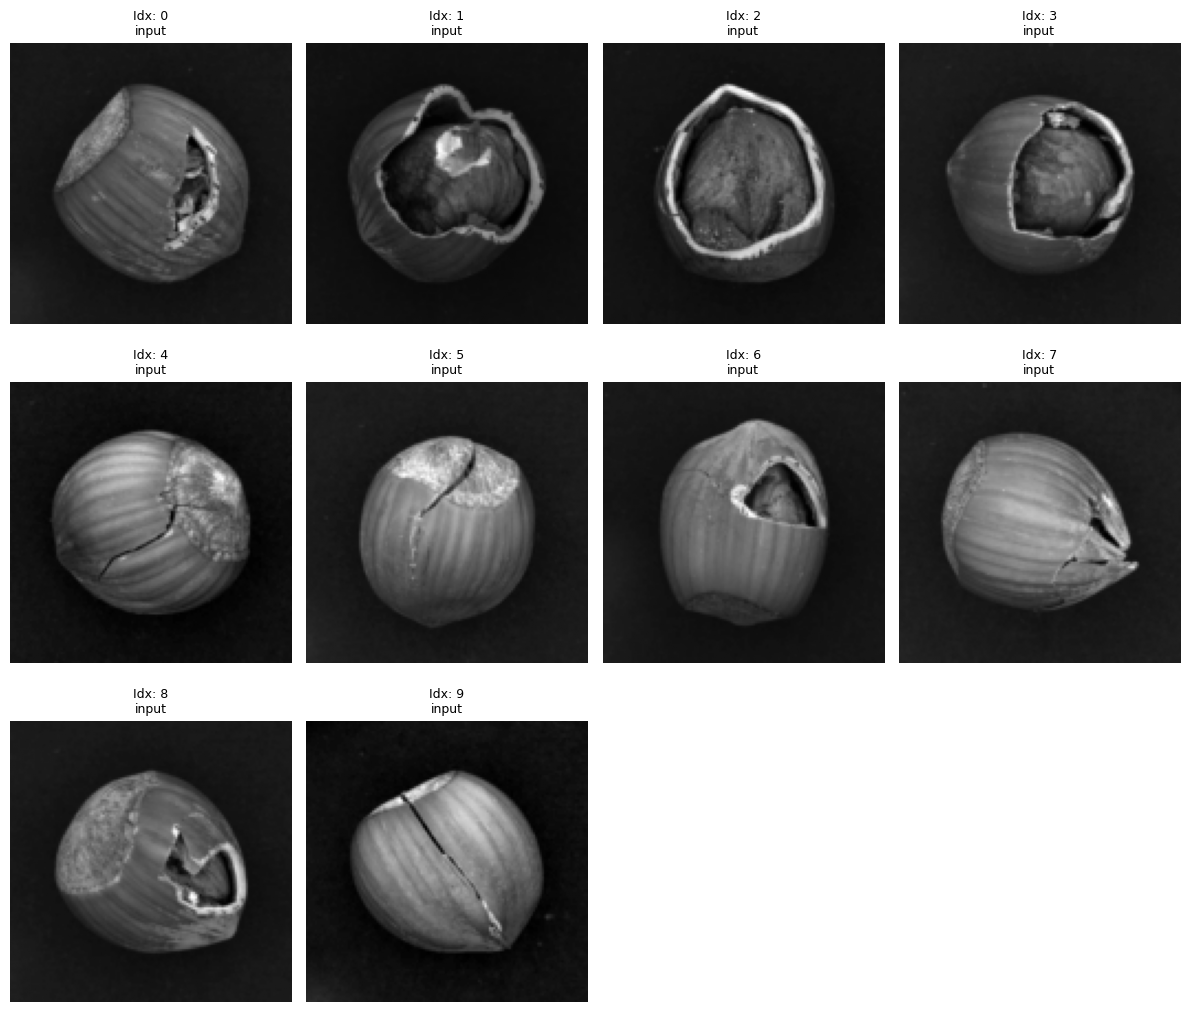

In [7]:
aug = Augmentor(rotation=0, tps=0, elastic=0, dense_noise=0, source_root=DATASET_PATH, device=DEVICE)
# aug.prepare(force_rebuild=True)
data = aug.get_dataset(
    transform=transforms.Compose([
        transforms.Resize(DIMS),
        transforms.Grayscale(num_output_channels=1),
        # transforms.ToTensor()
        UniversalNormalise()
    ])
)

# from data import FlatDataset
# data = FlatDataset(
#     root=DATASET_PATH + "/input", 
#     transform=transforms.Compose([
#         transforms.Resize(DIMS),
#         transforms.Grayscale(num_output_channels=1),
#         # transforms.ToTensor()
#         UniversalNormalise()
#     ])
# )

train_loader = DataLoader(data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
#only eval images 260-300
# eval_data = torch.utils.data.Subset(data, list(range(260, 270)))
eval_loader = DataLoader(data, batch_size=len(data), shuffle=False, num_workers=0)
rpca_eval_loader = DataLoader(data, batch_size=len(data), shuffle=False, num_workers=0)

data.visualise(num_images=10, start_idx=0)

In [8]:
models_dict = {}
torch.cuda.empty_cache()

In [9]:
rpca = get_model('RPCA', max_iter=6000, lambda_=None, tol=1e-7).to(DEVICE)
torch.cuda.empty_cache()

Trainer loaded to cuda:0

Training ceVAE Model...


Training:   0%|          | 0/60 [00:00<?, ?it/s]

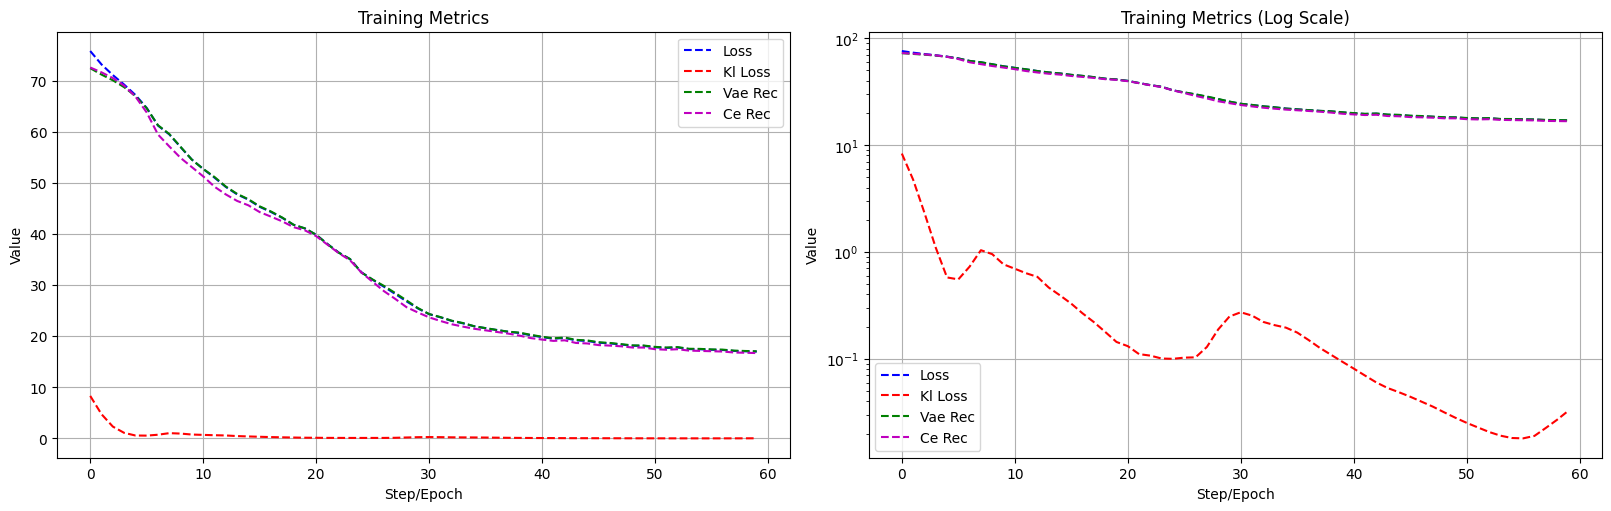

Training Complete. Final Avg Loss: 17.0121


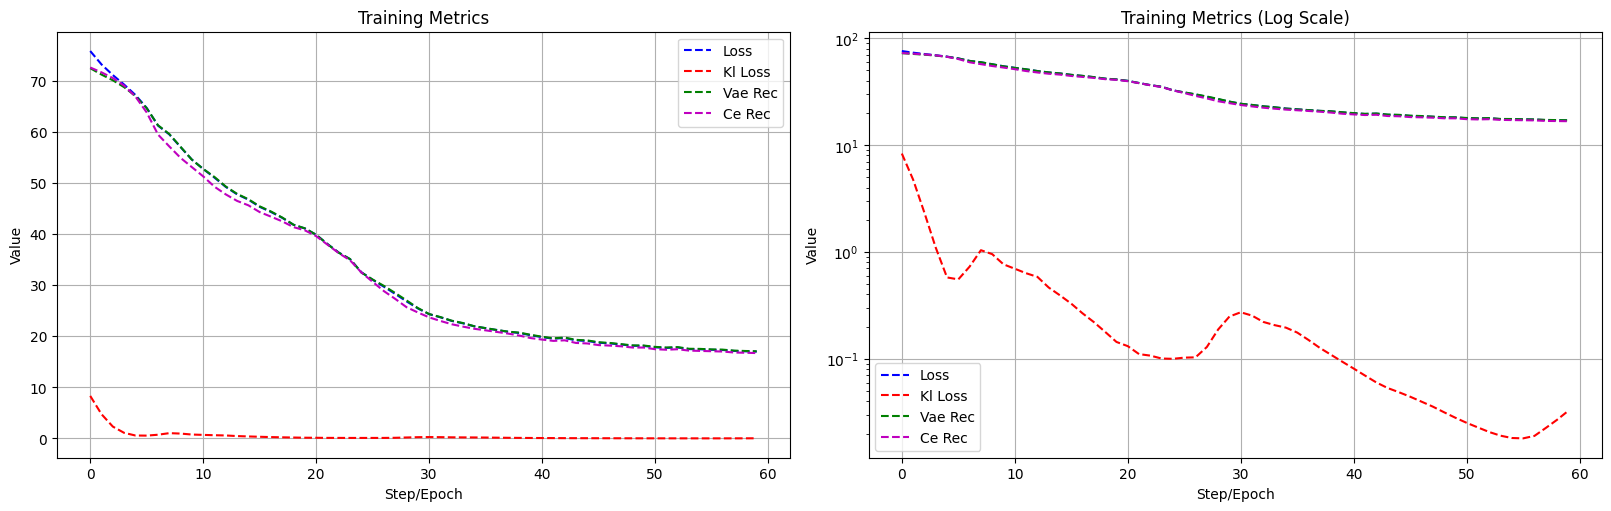

In [10]:
cevae = get_model('ceVAE', latent_channels=1024).to(DEVICE)
# trainer = get_trainer('Opus', model=cevae, loader=train_loader)
# trainer.fit(
#     outer_epochs=3, 
#     inner_epochs=20,
#     lr=2e-4,
#     lambda_=1.0 / torch.sqrt(torch.tensor(128))*3,
#     lambda_ce=0.8
# )    
trainer = get_trainer('ceVAE', model=cevae, loader=train_loader)
trainer.fit(
    epochs=60,
    lr=3e-4,
    lambda_=0.2,
    beta=0.5,
)
models_dict['ceVAE_Opus'] = cevae
del trainer
torch.cuda.empty_cache()

    # outer_epochs=10, 
    # inner_epochs=3,
    # lr=2e-4,
    # lambda_=1.0 / torch.sqrt(torch.tensor(128))*1,
    # lambda_ce=0.85


In [ ]:
for model in models_dict.values():
    model.eval()

batch = next(iter(eval_loader))
X_input, _, _ = batch 
rpca_batch = next(iter(rpca_eval_loader))
X_rpca_input, _, _ = rpca_batch

print(f"\nEvaluating on batch of size {X_input.shape[0]}...")
results_root = os.path.abspath(f"./results/{aug.dest_root.split('/')[-1]}/")

X_resized, L_rpca, S_rpca = get_rpca_decomposition(X_rpca_input, rpca, results_root, force_recompute=False, target_size=aug.init_dims)
model_results = run_deep_models_inference(X_input, models_dict, target_size=aug.init_dims, batch_size=BATCH_SIZE//2)

torch.cuda.empty_cache()


Evaluating on batch of size 398...
Found pre-computed RPCA results. Loading from disk...
Running Deep Models Inference...
Running ceVAE_Opus inference with custom anomaly generator...


c:\Users\joshu\repos\P114-Annotation-Free-Segmentation\.venv\Lib\site-packages\captum\attr\_core\guided_backprop_deconvnet.py:66: UserWarning: Setting backward hooks on ReLU activations.The hooks will be removed after the attribution is finished
  warnings.warn(


In [ ]:
truth = aug.get_gt_images()
# truth = None
start = 0
end = 100
visualise_results(
    X_resized[start:end], 
    L_rpca[start:end], 
    S_rpca[start:end], 
    {name: (L, S) for name, (L, S) in model_results.items()}, 
    truth[start:end] if truth is not None else None
)


In [ ]:

if truth is not None:
    shuffle_idx = torch.randperm(len(truth))
    shuffled_truth = truth[shuffle_idx]

    validation_truth = shuffled_truth[:len(shuffled_truth)//2]
    test_truth = shuffled_truth[len(shuffled_truth)//2:]

    shuffled_S_rpca = S_rpca[shuffle_idx]
    t, dice = find_optimal_dice(validation_truth, shuffled_S_rpca[:len(shuffled_truth)//2], bins=1000)
    # print(f"Optimal threshold for RPCA: {t} with dice score {dice}")
    test_dice = calculate_dice(test_truth, shuffled_S_rpca[len(shuffled_truth)//2:], threshold=t)
    print(f"Dice Score for RPCA on test set:\t {test_dice} at threshold {t:.4f}")

    for name, (L, S) in model_results.items():

        shuffled_S = S[shuffle_idx]
        t, dice = find_optimal_dice(validation_truth, shuffled_S[:len(shuffled_truth)//2], bins=1000)
        # print(f"Optimal threshold for {name}: {t} with dice score {dice}")
        test_dice = calculate_dice(test_truth, shuffled_S[len(shuffled_truth)//2:], threshold=t)
        print(f"Dice Score for {name} on test set:\t {test_dice} at threshold {t:.4f}")

# 0.51 guided leaky with full loss lambda 0.8
# 0.47 normal leaky with full loss
# 0.53 guided relu with full loss

# 0.58 guided relu full loss lambda 0.5

# leaky=False, guided=False/True. Dice Score for ceVAE: 0.6090211868286133
# leaky=True, guided=True. Dice Score for ceVAE: 0.4989464282989502
# leaky=True, guided=False. Dice Score for ceVAE: 0.5895518660545349

# leaky=True, guided=True. Dice Score for ceVAE: 0.5011835098266602

# best right now is ssm/kl loss for training and l1/kl for anomaly map no blurring
# doing a post processing anomaly map (l1 - ssim) looks good and removes tps but also removes too much of the cars
# Dice Score for ceVAE: 0.709871768951416 at threshold 0.08054477721452713
# testlambda085ssim

In [ ]:
print("Do you want to save the trained Autoencoder model? (y/n): ", end="")
save_choice = input().strip().lower()
if save_choice == 'y':
    model_name = "rddpm_lr1e-4_epoch10_huber02" 
    torch.save(rddpm.state_dict(), f"saved/rddpm/{model_name}.pth")
    print(f"Model saved as {model_name}.pth")
else:
    print("Model not saved.")

#ages was 1300 epochs